In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Make plots look better
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("✅ Libraries imported successfully!")
print("📊 Ready to simulate epidemic spread!")


✅ Libraries imported successfully!
📊 Ready to simulate epidemic spread!


In [2]:
POPULATION = 10000
INITIAL_INFECTED = 10
INITIAL_SUSCEPTIBLE = POPULATION - INITIAL_INFECTED
INITIAL_RECOVERED = 0

# Disease parameters (experiment with these!)
TRANSMISSION_RATE = 0.3    # 30% chance infected person spreads disease
RECOVERY_RATE = 0.1        # 10% of infected people recover each day
SIMULATION_DAYS = 100      # How many days to simulate

print(f"🏙️  Virtual City Setup:")
print(f"   Population: {POPULATION:,} people")
print(f"   Initial infected: {INITIAL_INFECTED}")
print(f"   Transmission rate: {TRANSMISSION_RATE*100}%")
print(f"   Recovery rate: {RECOVERY_RATE*100}%")
print(f"   Simulation period: {SIMULATION_DAYS} days")

🏙️  Virtual City Setup:
   Population: 10,000 people
   Initial infected: 10
   Transmission rate: 30.0%
   Recovery rate: 10.0%
   Simulation period: 100 days


In [3]:
def simulate_epidemic(population, initial_infected, transmission_rate, recovery_rate, days):
    """
    Simulate epidemic using SIR model
    
    S = Susceptible (can get infected)
    I = Infected (currently sick and contagious)  
    R = Recovered (immune)
    """
    
    # Initialize
    S = population - initial_infected
    I = initial_infected
    R = 0
    
    # Store results
    results = {
        'day': [],
        'susceptible': [],
        'infected': [],
        'recovered': [],
        'new_infections': [],
        'new_recoveries': []
    }
    
    print("🔄 Running epidemic simulation...")
    print("Day  | Susceptible | Infected | Recovered | New Cases")
    print("-" * 55)
    
    for day in range(days + 1):
        # Store today's data
        results['day'].append(day)
        results['susceptible'].append(S)
        results['infected'].append(I)
        results['recovered'].append(R)
        
        # Calculate new infections and recoveries
        new_infections = int(I * transmission_rate * (S / population))
        new_recoveries = int(I * recovery_rate)
        
        # Make sure we don't exceed limits
        new_infections = min(new_infections, S)
        new_recoveries = min(new_recoveries, I)
        
        results['new_infections'].append(new_infections)
        results['new_recoveries'].append(new_recoveries)
        
        # Print progress every 10 days
        if day % 10 == 0:
            print(f"{day:3d}  | {S:11d} | {I:8d} | {R:9d} | {new_infections:9d}")
        
        # Update for next day
        S = S - new_infections
        I = I + new_infections - new_recoveries
        R = R + new_recoveries
        
        # Stop if no more infected people
        if I == 0:
            print(f"✅ Epidemic ended on day {day}")
            break
    
    return pd.DataFrame(results)

# Run the simulation
epidemic_data = simulate_epidemic(
    POPULATION, INITIAL_INFECTED, TRANSMISSION_RATE, RECOVERY_RATE, SIMULATION_DAYS
)

print(f"\n📊 Simulation complete! Collected {len(epidemic_data)} days of data.")

🔄 Running epidemic simulation...
Day  | Susceptible | Infected | Recovered | New Cases
-------------------------------------------------------
  0  |        9990 |       10 |         0 |         2
 10  |        9927 |       54 |        19 |        16
 20  |        9527 |      320 |       153 |        91
 30  |        7632 |     1488 |       880 |       340
 40  |        3696 |     3098 |      3206 |       343
 50  |        1476 |     2390 |      6134 |       105
 60  |         845 |     1204 |      7951 |        30
 70  |         655 |      535 |      8810 |        10
 80  |         590 |      227 |      9183 |         4
 90  |         567 |       96 |      9337 |         1
100  |         561 |       40 |      9399 |         0

📊 Simulation complete! Collected 101 days of data.


In [4]:
peak_infections = epidemic_data['infected'].max()
peak_day = epidemic_data.loc[epidemic_data['infected'].idxmax(), 'day']
total_infected = epidemic_data['recovered'].max()
attack_rate = (total_infected / POPULATION) * 100

print("🔍 EPIDEMIC ANALYSIS RESULTS")
print("=" * 40)
print(f"📊 Peak infections: {peak_infections} people")
print(f"📅 Peak occurred on: Day {peak_day}")
print(f"🏥 Total people infected: {total_infected}")
print(f"📈 Attack rate: {attack_rate:.1f}% of population")
print(f"⏱️  Epidemic duration: {len(epidemic_data)} days")

# Show first and last few days
print("\n📋 First 5 days:")
print(epidemic_data[['day', 'susceptible', 'infected', 'recovered']].head())
print("\n📋 Last 5 days:")
print(epidemic_data[['day', 'susceptible', 'infected', 'recovered']].tail())

🔍 EPIDEMIC ANALYSIS RESULTS
📊 Peak infections: 3134 people
📅 Peak occurred on: Day 42
🏥 Total people infected: 9399
📈 Attack rate: 94.0% of population
⏱️  Epidemic duration: 101 days

📋 First 5 days:
   day  susceptible  infected  recovered
0    0         9990        10          0
1    1         9988        11          1
2    2         9985        13          2
3    3         9982        15          3
4    4         9978        18          4

📋 Last 5 days:
     day  susceptible  infected  recovered
96    96          561        58       9381
97    97          561        53       9386
98    98          561        48       9391
99    99          561        44       9395
100  100          561        40       9399


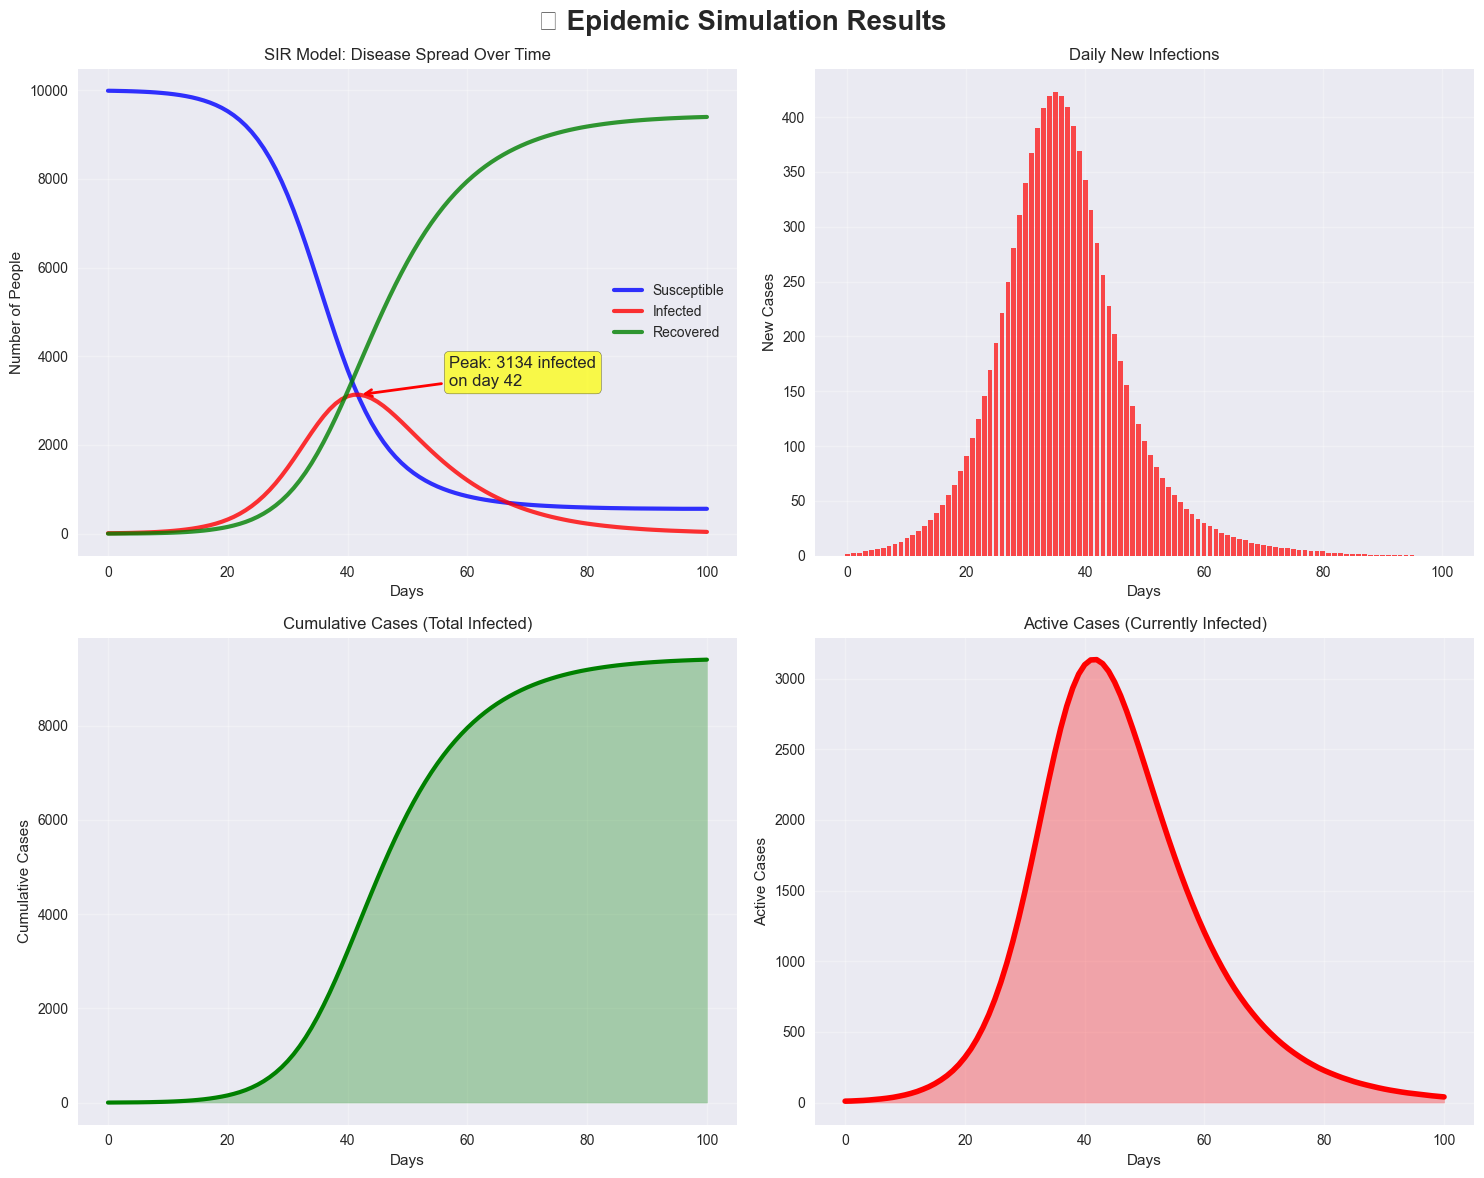

📈 Epidemic visualization complete!


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('🦠 Epidemic Simulation Results', fontsize=20, fontweight='bold')

# Plot 1: Main SIR curves
ax1 = axes[0, 0]
ax1.plot(epidemic_data['day'], epidemic_data['susceptible'], 'b-', linewidth=3, label='Susceptible', alpha=0.8)
ax1.plot(epidemic_data['day'], epidemic_data['infected'], 'r-', linewidth=3, label='Infected', alpha=0.8)
ax1.plot(epidemic_data['day'], epidemic_data['recovered'], 'g-', linewidth=3, label='Recovered', alpha=0.8)
ax1.set_title('SIR Model: Disease Spread Over Time')
ax1.set_xlabel('Days')
ax1.set_ylabel('Number of People')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Annotate peak
ax1.annotate(f'Peak: {peak_infections} infected\non day {peak_day}', 
             xy=(peak_day, peak_infections), 
             xytext=(peak_day + 15, peak_infections + 200),
             arrowprops=dict(arrowstyle='->', color='red', lw=2),
             bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))

# Plot 2: Daily new cases
ax2 = axes[0, 1]
ax2.bar(epidemic_data['day'], epidemic_data['new_infections'], color='red', alpha=0.7, width=0.8)
ax2.set_title('Daily New Infections')
ax2.set_xlabel('Days')
ax2.set_ylabel('New Cases')
ax2.grid(True, alpha=0.3)

# Plot 3: Cumulative cases
ax3 = axes[1, 0]
ax3.plot(epidemic_data['day'], epidemic_data['recovered'], 'g-', linewidth=3)
ax3.fill_between(epidemic_data['day'], epidemic_data['recovered'], alpha=0.3, color='green')
ax3.set_title('Cumulative Cases (Total Infected)')
ax3.set_xlabel('Days')
ax3.set_ylabel('Cumulative Cases')
ax3.grid(True, alpha=0.3)

# Plot 4: Active cases focus
ax4 = axes[1, 1]
ax4.plot(epidemic_data['day'], epidemic_data['infected'], 'r-', linewidth=4)
ax4.fill_between(epidemic_data['day'], epidemic_data['infected'], alpha=0.3, color='red')
ax4.set_title('Active Cases (Currently Infected)')
ax4.set_xlabel('Days')
ax4.set_ylabel('Active Cases')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("📈 Epidemic visualization complete!")

🧪 SCENARIO COMPARISON
🔄 Running epidemic simulation...
Day  | Susceptible | Infected | Recovered | New Cases
-------------------------------------------------------
  0  |        9990 |       10 |         0 |         2
 10  |        9927 |       54 |        19 |        16
 20  |        9527 |      320 |       153 |        91
 30  |        7632 |     1488 |       880 |       340
 40  |        3696 |     3098 |      3206 |       343
 50  |        1476 |     2390 |      6134 |       105
 60  |         845 |     1204 |      7951 |        30
 70  |         655 |      535 |      8810 |        10
 80  |         590 |      227 |      9183 |         4
 90  |         567 |       96 |      9337 |         1
100  |         561 |       40 |      9399 |         0

Scenario 1 (Baseline):
  Transmission: 30.0%, Recovery: 10.0%
  Peak infections: 3134
  Total infected: 9399 (94.0%)
  Duration: 101 days
🔄 Running epidemic simulation...
Day  | Susceptible | Infected | Recovered | New Cases
---------------

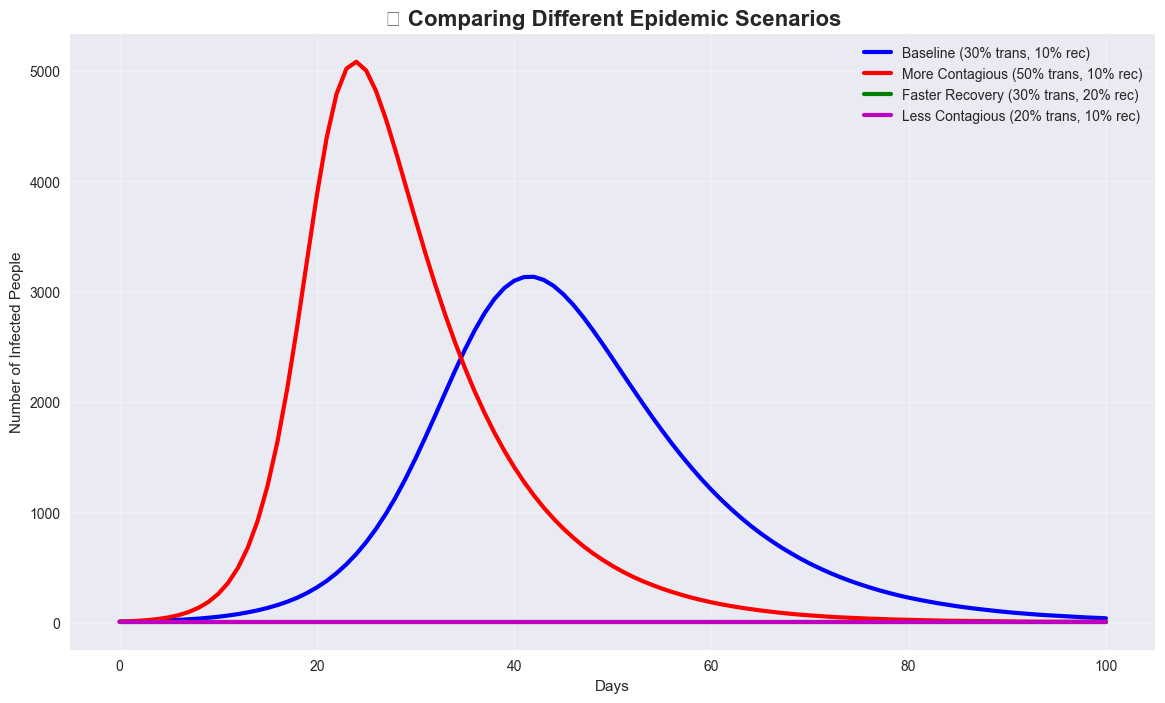


🎯 Key Insights:
• Higher transmission rate = higher peak, more total cases
• Higher recovery rate = lower peak, shorter duration
• These parameters critically affect healthcare demand!


In [6]:
def quick_simulation(transmission_rate, recovery_rate, label="Scenario"):
    """Quick simulation for comparing scenarios"""
    data = simulate_epidemic(POPULATION, INITIAL_INFECTED, transmission_rate, recovery_rate, 100)
    peak = data['infected'].max()
    total = data['recovered'].max()
    duration = len(data[data['infected'] > 0])
    
    print(f"\n{label}:")
    print(f"  Transmission: {transmission_rate*100}%, Recovery: {recovery_rate*100}%")
    print(f"  Peak infections: {peak}")
    print(f"  Total infected: {total} ({total/POPULATION*100:.1f}%)")
    print(f"  Duration: {duration} days")
    
    return data

print("🧪 SCENARIO COMPARISON")
print("=" * 50)

# Scenario 1: Current parameters
scenario1 = quick_simulation(0.3, 0.1, "Scenario 1 (Baseline)")

# Scenario 2: More contagious disease
scenario2 = quick_simulation(0.5, 0.1, "Scenario 2 (More Contagious)")

# Scenario 3: Faster recovery
scenario3 = quick_simulation(0.3, 0.2, "Scenario 3 (Faster Recovery)")

# Scenario 4: Less contagious
scenario4 = quick_simulation(0.2, 0.1, "Scenario 4 (Less Contagious)")

# Plot comparison
plt.figure(figsize=(14, 8))
plt.plot(scenario1['day'], scenario1['infected'], 'b-', linewidth=3, label='Baseline (30% trans, 10% rec)')
plt.plot(scenario2['day'], scenario2['infected'], 'r-', linewidth=3, label='More Contagious (50% trans, 10% rec)')
plt.plot(scenario3['day'], scenario3['infected'], 'g-', linewidth=3, label='Faster Recovery (30% trans, 20% rec)')
plt.plot(scenario4['day'], scenario4['infected'], 'm-', linewidth=3, label='Less Contagious (20% trans, 10% rec)')

plt.title('🔬 Comparing Different Epidemic Scenarios', fontsize=16, fontweight='bold')
plt.xlabel('Days')
plt.ylabel('Number of Infected People')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n🎯 Key Insights:")
print("• Higher transmission rate = higher peak, more total cases")
print("• Higher recovery rate = lower peak, shorter duration")
print("• These parameters critically affect healthcare demand!")

In [7]:
epidemic_data.to_csv('epidemic_simulation_results.csv', index=False)
print("💾 Results saved to 'epidemic_simulation_results.csv'")

💾 Results saved to 'epidemic_simulation_results.csv'
